In [1]:
# %pip uninstall numpy pandas scipy mne
# %pip install numpy pandas scipy mne

import numpy as np
import pandas as pd
import mne

C:\Users\Admin\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Admin\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
a = pd.read_csv('C:/bt23ece064/dataset/annotations_2017_A_fixed.csv')
b = pd.read_csv('C:/bt23ece064/dataset/annotations_2017_B.csv')
c = pd.read_csv('C:/bt23ece064/dataset/annotations_2017_C.csv')

In [3]:
# Your bipolar_pairs list
bipolar_pairs = [
    ('EEG Fp1-REF', 'EEG F7-REF'),
    ('EEG F7-REF',  'EEG T3-REF'),
    ('EEG T3-REF',  'EEG T5-REF'),
    ('EEG T5-REF',  'EEG O1-REF'),
    ('EEG Fp1-REF', 'EEG F3-REF'),
    ('EEG F3-REF',  'EEG C3-REF'),
    ('EEG C3-REF',  'EEG P3-REF'),
    ('EEG P3-REF',  'EEG O1-REF'),
    ('EEG Fz-REF',  'EEG Cz-REF'),
    ('EEG Cz-REF',  'EEG Pz-REF'),
    ('EEG Fp2-REF', 'EEG F4-REF'),
    ('EEG F4-REF',  'EEG C4-REF'),
    ('EEG C4-REF',  'EEG P4-REF'),
    ('EEG P4-REF',  'EEG O2-REF'),
    ('EEG Fp2-REF', 'EEG F8-REF'),
    ('EEG F8-REF',  'EEG T4-REF'),
    ('EEG T4-REF',  'EEG T6-REF'),
    ('EEG T6-REF',  'EEG O2-REF'),
]

desired_order = [
    'Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2',
    'Fp1-F7', 'F7-T3', 'T3-T5', 'T5-O1',
    'Fz-Cz', 'Cz-Pz',
]

def pair_name(pair):
    # Extract labels removing 'EEG ' and '-REF'
    left = pair[0].replace('EEG ', '').replace('-REF', '')
    right = pair[1].replace('EEG ', '').replace('-REF', '')
    return f"{left}-{right}"

# Create a dict from name to pair for quick lookup
name_to_pair = {pair_name(p): p for p in bipolar_pairs}

# Reorder bipolar_pairs according to desired_order
reordered_pairs = [name_to_pair[name] for name in desired_order]

# Let's print to verify
for name, pair in zip(desired_order, reordered_pairs):
    print(f"{name}: {pair}")


Fp2-F4: ('EEG Fp2-REF', 'EEG F4-REF')
F4-C4: ('EEG F4-REF', 'EEG C4-REF')
C4-P4: ('EEG C4-REF', 'EEG P4-REF')
P4-O2: ('EEG P4-REF', 'EEG O2-REF')
Fp1-F3: ('EEG Fp1-REF', 'EEG F3-REF')
F3-C3: ('EEG F3-REF', 'EEG C3-REF')
C3-P3: ('EEG C3-REF', 'EEG P3-REF')
P3-O1: ('EEG P3-REF', 'EEG O1-REF')
Fp2-F8: ('EEG Fp2-REF', 'EEG F8-REF')
F8-T4: ('EEG F8-REF', 'EEG T4-REF')
T4-T6: ('EEG T4-REF', 'EEG T6-REF')
T6-O2: ('EEG T6-REF', 'EEG O2-REF')
Fp1-F7: ('EEG Fp1-REF', 'EEG F7-REF')
F7-T3: ('EEG F7-REF', 'EEG T3-REF')
T3-T5: ('EEG T3-REF', 'EEG T5-REF')
T5-O1: ('EEG T5-REF', 'EEG O1-REF')
Fz-Cz: ('EEG Fz-REF', 'EEG Cz-REF')
Cz-Pz: ('EEG Cz-REF', 'EEG Pz-REF')


In [4]:
bipolar_pairs = [
    ('EEG Fp1-REF', 'EEG F7-REF'),
    ('EEG F7-REF',  'EEG T3-REF'),
    ('EEG T3-REF',  'EEG T5-REF'),
    ('EEG T5-REF',  'EEG O1-REF'),
    ('EEG Fp1-REF', 'EEG F3-REF'),
    ('EEG F3-REF',  'EEG C3-REF'),
    ('EEG C3-REF',  'EEG P3-REF'),
    ('EEG P3-REF',  'EEG O1-REF'),
    ('EEG Fz-REF',  'EEG Cz-REF'),
    ('EEG Cz-REF',  'EEG Pz-REF'),
    ('EEG Fp2-REF', 'EEG F4-REF'),
    ('EEG F4-REF',  'EEG C4-REF'),
    ('EEG C4-REF',  'EEG P4-REF'),
    ('EEG P4-REF',  'EEG O2-REF'),
    ('EEG Fp2-REF', 'EEG F8-REF'),
    ('EEG F8-REF',  'EEG T4-REF'),
    ('EEG T4-REF',  'EEG T6-REF'),
    ('EEG T6-REF',  'EEG O2-REF'),
]

def normalize_channel(ch):
    return ch.strip().upper()

bipolar_pairs = [(normalize_channel(a), normalize_channel(b)) for a, b in bipolar_pairs]

def make_ch_names(pairs):
    def pretty(ch):
        return ch.replace('EEG ', '').replace('-REF', '').capitalize()
    return [f"{pretty(a)}-{pretty(b)}" for a, b in pairs]

anode = [a for a, _ in bipolar_pairs]
cathode = [b for _, b in bipolar_pairs]
ch_names = make_ch_names(reordered_pairs)

In [5]:

def getArray(filename: str):
    raw = mne.io.read_raw_edf(filename, preload=True)
    raw.rename_channels(lambda ch: ch.upper())
    drop_candidates = ['ECG EKG', 'RESP EFFORT','ECG EKG-REF','RESP EFFORT-REF']
    available = set(raw.ch_names)
    to_drop = [ch for ch in drop_candidates if ch in available]
    if to_drop:
        raw.drop_channels(to_drop)
    raw = mne.set_bipolar_reference(raw, anode=anode, cathode=cathode, ch_name=ch_names, copy=True)
    array = raw.get_data()
    # raw.plot()
    return array


In [6]:
import os

eeg_set = []
for i in range(1, 80):
    filepath = f'C:/bt23ece064/dataset/eeg{i}.edf'
    if os.path.exists(filepath):
        try:
            eeg = getArray(filepath)
            eeg_set.append(eeg)
        except ValueError as e:
            print(f"Error in file: {filepath}")
            print(e)

Extracting EDF parameters from C:\bt23ece064\dataset\eeg79.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 844031  =      0.000 ...  3296.996 secs...


C:\Users\Admin\AppData\Local\Temp\ipykernel_8140\1641202550.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_8140\1641202550.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=844032
    Range : 0 ... 844031 =      0.000 ...  3296.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz


In [7]:
len(eeg_set)

79

In [8]:
# %pip install --upgrade openpyxl 
annotations = pd.read_excel('C:/bt23ece064/dataset/seizure_per_channel_Dec_2017.xlsx')

In [9]:
annotations

,FILE ID,Start,Stop,Fp2-F4,F4-C4,C4-P4,P4-O2,Fp1-F3,F3-C3,C3-P3,...,Fp2-F8,F8-T4,T4-T6,T6-O2,Fp1-F7,F7-T3,T3-T5,T5-O1,Fz-Cz,Cz-Pz
0,NaN,NaN,NaN,1,2,3,4,5,6,7,...,9,10,11,12,13,14,15,16,17,18
1,1.0,104.0,122.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
2,1.0,349.0,428.0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,1.0,760.0,779.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
4,1.0,956.0,965.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,79.0,152.0,190.0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
361,79.0,367.0,384.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
362,79.0,576.0,621.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
363,79.0,2148.0,2163.0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
annotations = annotations.sort_values(by=['FILE ID','Start'], ascending=[True,True])

In [11]:
annotations = annotations.dropna(axis=0)

In [12]:
annotations

,FILE ID,Start,Stop,Fp2-F4,F4-C4,C4-P4,P4-O2,Fp1-F3,F3-C3,C3-P3,...,Fp2-F8,F8-T4,T4-T6,T6-O2,Fp1-F7,F7-T3,T3-T5,T5-O1,Fz-Cz,Cz-Pz
1,1.0,104.0,122.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
2,1.0,349.0,428.0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,1.0,760.0,779.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
4,1.0,956.0,965.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
5,1.0,973.0,982.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,79.0,152.0,190.0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
361,79.0,367.0,384.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
362,79.0,576.0,621.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
363,79.0,2148.0,2163.0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
iter = annotations.columns[3:]
iter

Index(['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'Fp1-F3', 'F3-C3', 'C3-P3',
       'P3-O1', 'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2', 'Fp1-F7', 'F7-T3',
       'T3-T5', 'T5-O1', 'Fz-Cz', 'Cz-Pz'],
      dtype='object')

In [14]:
# for i in range(364):
#     patient = annotations['FILE ID'].iloc[i]
#     start = annotations['Start'].iloc[i]
#     end = annotations['End'].iloc[i]
#     for col_idx,col in enumerate(iter):
#         if annotations[col].iloc[i] == 1:
#             for ran in range(start*256, end*256):
#                 seizured_segments[patient][col_idx][start*256:end*256] = eeg_set[patient][col_idx][start*256:end*256]
                




In [15]:
eeg_set[0][0]

array([0.00000000e+00, 1.52587771e-07, 1.06811440e-06, ...,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [16]:
import numpy as np


seizured_segments = [
    [np.zeros_like(channel, dtype=float) for channel in patient_eeg] 
    for patient_eeg in eeg_set
]
non_seizured_segments = [
    [np.zeros_like(channel, dtype=float) for channel in patient_eeg] 
    for patient_eeg in eeg_set
]


unordered_seizured_segments = []
unordered_non_seizured_segments = []

channel_cols = ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'Fp1-F3', 'F3-C3', 'C3-P3',
                'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2', 'Fp1-F7', 'F7-T3', 'T3-T5', 
                'T5-O1', 'Fz-Cz', 'Cz-Pz']

print(f"Starting processing {len(annotations)} annotations...")
print(f"Total patients in eeg_set: {len(eeg_set)}")


for i in range(len(annotations)):
    patient = int(annotations['FILE ID'].iloc[i] - 1)
    start = int(annotations['Start'].iloc[i] * 256) 
    stop = int(annotations['Stop'].iloc[i] * 256)
    
    
    print(f"Processing annotation {i+1}/{len(annotations)} - Patient {patient+1}, Time: {annotations['Start'].iloc[i]:.1f}s-{annotations['Stop'].iloc[i]:.1f}s")
    
    seizure_count = 0
    non_seizure_count = 0
    
    for ch_idx, col in enumerate(channel_cols):
        if ch_idx < len(eeg_set[patient]): 
            if annotations[col].iloc[i] == 1: 
                seizured_segments[patient][ch_idx][start:stop] = eeg_set[patient][ch_idx][start:stop]
                non_seizured_segments[patient][ch_idx][start:stop] = 0
                unordered_seizured_segments.append(eeg_set[patient][ch_idx][start:stop])
                seizure_count += 1
            else:  
                seizured_segments[patient][ch_idx][start:stop] = 0
                non_seizured_segments[patient][ch_idx][start:stop] = eeg_set[patient][ch_idx][start:stop]
                unordered_non_seizured_segments.append(eeg_set[patient][ch_idx][start:stop])
                non_seizure_count += 1
    
    print(f"  Annotation {i+1}: {seizure_count} seizure channels, {non_seizure_count} non-seizure channels")

print("\nProcessing complete!")
print(f"Total annotations processed: {len(annotations)}")




Starting processing 364 annotations...
Total patients in eeg_set: 79
Processing annotation 1/364 - Patient 1, Time: 104.0s-122.0s
  Annotation 1: 2 seizure channels, 15 non-seizure channels
Processing annotation 2/364 - Patient 1, Time: 349.0s-428.0s
  Annotation 2: 2 seizure channels, 15 non-seizure channels
Processing annotation 3/364 - Patient 1, Time: 760.0s-779.0s
  Annotation 3: 2 seizure channels, 15 non-seizure channels
Processing annotation 4/364 - Patient 1, Time: 956.0s-965.0s
  Annotation 4: 2 seizure channels, 15 non-seizure channels
Processing annotation 5/364 - Patient 1, Time: 973.0s-982.0s
  Annotation 5: 2 seizure channels, 15 non-seizure channels
Processing annotation 6/364 - Patient 1, Time: 1179.0s-1195.0s
  Annotation 6: 2 seizure channels, 15 non-seizure channels
Processing annotation 7/364 - Patient 1, Time: 1601.0s-1613.0s
  Annotation 7: 1 seizure channels, 16 non-seizure channels
Processing annotation 8/364 - Patient 1, Time: 1622.0s-1632.0s
  Annotation 8: 2

In [17]:
import matplotlib.pyplot as plt

def plot_seizure_segments_for_patient(patient_id, seizure_segments_list):
    segment_2d = seizure_segments_list[patient_id]
    n_channels = 18

    plt.figure(figsize=(12, 3 * n_channels))
    plt.suptitle(f"Seizure Segments - Patient {patient_id + 1}")

    for ch in range(n_channels):
        plt.subplot(n_channels, 1, ch + 1)
        plt.plot(segment_2d[ch])
        plt.title(f"Channel {ch + 1}")
        plt.xlabel("Samples")
        plt.ylabel("Amplitude")
        plt.grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


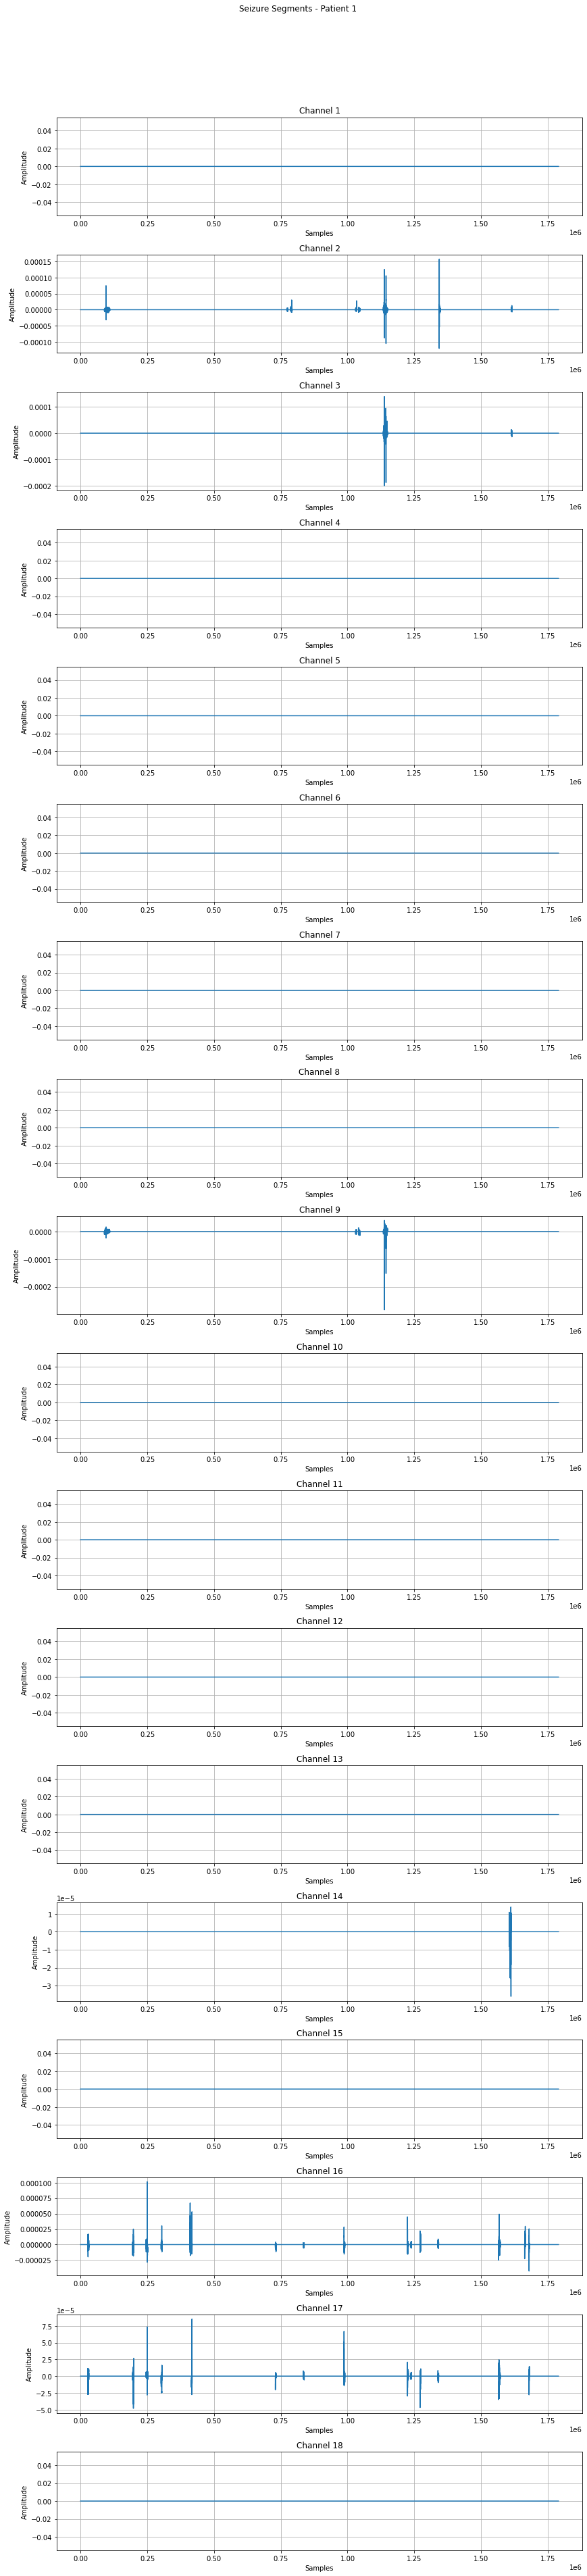

In [18]:
plot_seizure_segments_for_patient(0,seizure_segments_list=seizured_segments)

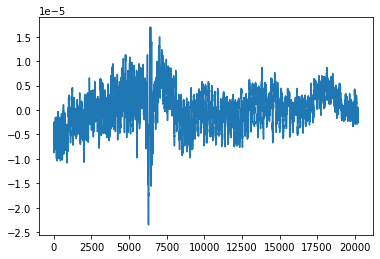

In [22]:
plt.plot(unordered_seizured_segments[3])

In [19]:
import numpy as np

class LinearRegression:
    """
    Ordinary least squares Linear Regression.
    
    This class implements the same API as sklearn.linear_model.LinearRegression
    but with a simpler implementation using numpy.
    
    Parameters
    ----------
    fit_intercept : bool, default=True
        Whether to calculate the intercept for this model. If set to False, no intercept
        will be used in calculations (i.e. data is expected to be centered).
    
    copy_X : bool, default=True
        If True, X will be copied; else, it may be overwritten.
    
    n_jobs : int, default=None
        The number of jobs to use for the computation. This parameter is kept for API
        compatibility but is not used in this implementation.
    
    positive : bool, default=False
        When set to True, forces the coefficients to be positive. This parameter is kept
        for API compatibility but is not used in this implementation.
    
    Attributes
    ----------
    coef_ : array of shape (n_features,) or (n_targets, n_features)
        Estimated coefficients for the linear regression problem.
    
    intercept_ : float or array of shape (n_targets,)
        Independent term in the linear model.
    
    rank_ : int
        Rank of matrix X.
    
    singular_ : array of shape (min(X, y),)
        Singular values of X.
    """
    
    def __init__(self, fit_intercept=True, copy_X=True, n_jobs=None, positive=False):
        self.fit_intercept = fit_intercept
        self.copy_X = copy_X
        self.n_jobs = n_jobs
        self.positive = positive
        self.coef_ = None
        self.intercept_ = None
        self.rank_ = None
        self.singular_ = None
    
    def fit(self, X, y):
        """
        Fit linear model.
        
        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Training data
        
        y : array-like of shape (n_samples,) or (n_samples, n_targets)
            Target values
        
        Returns
        -------
        self : returns an instance of self
        """
        X = np.asarray(X)
        y = np.asarray(y)
        
        if self.copy_X:
            X = X.copy()
        
        # Handle 1D arrays
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        
        n_samples, n_features = X.shape
        
        if self.fit_intercept:
            # Add column of ones for intercept
            X = np.column_stack([np.ones(n_samples), X])
        
        # Compute the least squares solution using numpy's lstsq
        # This is equivalent to: (X^T X)^(-1) X^T y
        try:
            # Use numpy's lstsq for better numerical stability
            beta, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)
            
            if self.fit_intercept:
                self.intercept_ = beta[0]
                self.coef_ = beta[1:]
            else:
                self.intercept_ = 0.0
                self.coef_ = beta
            
            self.rank_ = rank
            self.singular_ = s
            
        except np.linalg.LinAlgError:
            raise ValueError("Singular matrix in linear regression")
        
        return self
    
    def predict(self, X):
        """
        Predict using the linear model.
        
        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Samples
        
        Returns
        -------
        C : array of shape (n_samples,)
            Returns predicted values
        """
        if self.coef_ is None:
            raise ValueError("Model has not been fitted yet. Call 'fit' before using this method.")
        
        X = np.asarray(X)
        
        # Handle 1D arrays
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        if self.fit_intercept:
            return np.dot(X, self.coef_) + self.intercept_
        else:
            return np.dot(X, self.coef_)
    
    def score(self, X, y):
        """
        Return the coefficient of determination R^2 of the prediction.
        
        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Test samples
        
        y : array-like of shape (n_samples,) or (n_samples, n_targets)
            True values for X
        
        Returns
        -------
        score : float
            R^2 of self.predict(X) wrt. y
        """
        if self.coef_ is None:
            raise ValueError("Model has not been fitted yet. Call 'fit' before using this method.")
        
        X = np.asarray(X)
        y = np.asarray(y)
        
        # Handle 1D arrays
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        
        y_pred = self.predict(X)
        
        # Calculate R^2
        ss_tot = np.sum((y - np.mean(y, axis=0)) ** 2, axis=0)
        ss_res = np.sum((y - y_pred) ** 2, axis=0)
        r2 = 1 - (ss_res / ss_tot)
        
        return r2.mean() if r2.size > 1 else r2.item()

In [33]:
def get_df(segments, band=(8, 12), fs=256, feature="slope"):
    import numpy as np
    from sklearn.linear_model import LinearRegression
    from scipy.signal import welch, butter, filtfilt
    import pandas as pd

    def bandpass_filter(data, lowcut, highcut, fs, order=4):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return filtfilt(b, a, data)

    if segments is None or len(segments) == 0:
        return pd.DataFrame()

    n_segments = len(segments)
    values = np.zeros(n_segments)

    for seg_idx, segment in enumerate(segments):
        # Check length for filtfilt
        min_len = 3 * (max(len(butter(4, [band[0]/(0.5*fs), band[1]/(0.5*fs)], btype='band')[0]), 
                           len(butter(4, [band[0]/(0.5*fs), band[1]/(0.5*fs)], btype='band')[1])) - 1)
        if len(segment) <= min_len:
            # Skip or handle short segments appropriately
            values[seg_idx] = np.nan
            continue
        
        filtered_segment = bandpass_filter(segment, band[0], band[1], fs)
        f, Pxx = welch(filtered_segment, fs=fs, nperseg=512)
        freq_mask = (f >= band[0]) & (f <= band[1])
        f_filtered = f[freq_mask]
        Pxx_filtered = Pxx[freq_mask]
        log_Pxx = np.log10(Pxx_filtered + 1e-12)
        model = LinearRegression()
        model.fit(f_filtered.reshape(-1, 1), log_Pxx)

        if feature == "slope":
            values[seg_idx] = model.coef_[0]
        elif feature == "intercept":
            values[seg_idx] = model.intercept_
        elif feature == "midband":
            midband_freq = 10.0
            values[seg_idx] = model.predict([[midband_freq]])[0]
        else:
            raise ValueError("feature must be 'slope', 'intercept', or 'midband'")

    df_result = pd.DataFrame(values, columns=[feature], index=[f'Seg{s+1}' for s in range(n_segments)])

    return df_result


In [34]:
def t_test(annotator, band=(8, 12)):  # Default to alpha band
    # Define all frequency bands
    FREQUENCY_BANDS = {
        'gamma': (35, 100),  
        'beta': (12, 35),
        'alpha': (8, 12),
        'theta': (4, 8),
        'delta': (0.5, 4)
    }
    
    all_seizured_segments = unordered_seizured_segments
    all_non_seizured_segments = unordered_non_seizured_segments

    for file_idx, array in enumerate(eeg_set):
        print(f"Processing file {file_idx + 1}/{len(eeg_set)}")
        

        
   
        
    


    print(f"Processing complete! Processed {len(eeg_set)} files.")
    print(f"Structure: all_seizured_segments[file_idx][channel_idx][segment_idx]")
    print(f"Analyzing frequency band: {band[0]}-{band[1]} Hz")

    # ... [keep existing get_df function as is] ...

    # Process all files and extract features (slope, intercept, and midband)
    all_seizure_features_slope = []  
    all_non_seizure_features_slope = []  
    all_seizure_features_intercept = []  
    all_non_seizure_features_intercept = []  
    all_seizure_features_midband = []  
    all_non_seizure_features_midband = []  

    for file_idx in range(len(all_seizured_segments)):
        # Extract slope features
        seizure_slope_df = get_df(all_seizured_segments[file_idx], band=band, fs=256, feature="slope")
        non_seizure_slope_df = get_df(all_non_seizured_segments[file_idx], band=band, fs=256, feature="slope")
        all_seizure_features_slope.append(seizure_slope_df)
        all_non_seizure_features_slope.append(non_seizure_slope_df)
        
        # Extract intercept features
        seizure_intercept_df = get_df(all_seizured_segments[file_idx], band=band, fs=256, feature="intercept")
        non_seizure_intercept_df = get_df(all_non_seizured_segments[file_idx], band=band, fs=256, feature="intercept")
        all_seizure_features_intercept.append(seizure_intercept_df)
        all_non_seizure_features_intercept.append(non_seizure_intercept_df)
        
        # Extract midband features
        seizure_midband_df = get_df(all_seizured_segments[file_idx], band=band, fs=256, feature="midband")
        non_seizure_midband_df = get_df(all_non_seizured_segments[file_idx], band=band, fs=256, feature="midband")
        all_seizure_features_midband.append(seizure_midband_df)
        all_non_seizure_features_midband.append(non_seizure_midband_df)
        
        # Print summary for current file
        seizure_count = seizure_slope_df.shape[1] if not seizure_slope_df.empty else 0
        non_seizure_count = non_seizure_slope_df.shape[1] if not non_seizure_slope_df.empty else 0
        print(f"  File {file_idx}: {seizure_count} seizure segments, {non_seizure_count} non-seizure segments")

    # ... [keep existing code for combining features] ...
    cs_s = np.concatenate([df.values.flatten() for df in all_seizure_features_slope])
    cs_ns = np.concatenate([df.values.flatten() for df in all_non_seizure_features_slope])
    ci_s = np.concatenate([df.values.flatten() for df in all_seizure_features_intercept])
    ci_ns = np.concatenate([df.values.flatten() for df in all_non_seizure_features_intercept])
    cm_s = np.concatenate([df.values.flatten() for df in all_seizure_features_midband])
    cm_ns = np.concatenate([df.values.flatten() for df in all_non_seizure_features_midband])
    from scipy.stats import ttest_ind
    t_slope, p_slope = ttest_ind(cs_s, cs_ns, equal_var=False)
    t_intercept, p_intercept = ttest_ind(ci_s, ci_ns, equal_var=False)
    t_midband, p_midband = ttest_ind(cm_s, cm_ns, equal_var=False)
    
    # Get band name from frequency range
    band_name = next((name for name, (low, high) in FREQUENCY_BANDS.items() 
                     if low == band[0] and high == band[1]), f"{band[0]}-{band[1]}Hz")
    
    print(f"\nResults for {band_name} band:")
    print(f"Slope     → t = {t_slope:.4f}, p = {p_slope:.4e}")
    print(f"Intercept → t = {t_intercept:.4f}, p = {p_intercept:.4e}")
    print(f"Midband   → t = {t_midband:.4f}, p = {p_midband:.4e}")
    
    # Create results directory if it doesn't exist
    import os
    os.makedirs('results', exist_ok=True)
   # Save t-test results
    ttest_results = pd.DataFrame({
        'Band': [band_name] * 3,
        'Feature': ['Slope', 'Intercept', 'Midband'],
        't_value': [t_slope, t_intercept, t_midband],
        'p_value': [p_slope, p_intercept, p_midband]
    })
    ttest_results.to_csv(os.path.join('results', f't_test_results_{band_name}.csv'), index=False)

In [ ]:

# Frequency bands
FREQUENCY_BANDS = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 35),
    'gamma': (35, 100)
}

# Annotator dictionary
annotators = {'a': a, 'b': b, 'c': c}

# Run the t-test for all bands and annotators
for band_name, band_range in FREQUENCY_BANDS.items():
    print(f"\n🔍 Processing band: {band_name} ({band_range[0]}–{band_range[1]} Hz)")

    for annotator_label, annotator_data in annotators.items():
        print(f"➡️  Annotator: {annotator_label}")

        # Create per-annotator results folder
        results_dir = os.path.join('results', f"{annotator_label}/{band_name}")
        os.makedirs(results_dir, exist_ok=True)

        # Run t-test function (assumes results_dir is global or passed in)
        t_test(annotator=annotator_data, band=band_range)

In [ ]:
for i in seizured_segments:
    plt.plot(i)
    plt.title(len(i))